In [1]:
import os, sys, time
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
sys.path.append('..')
%matplotlib inline

In [2]:
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 6.0
plt.rcParams['ytick.major.size'] = 6.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.minor.size'] = 4.0
plt.rcParams['ytick.minor.size'] = 4.0
plt.rcParams['xtick.minor.width'] = 0.8
plt.rcParams['ytick.minor.width'] = 0.8
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['font.size'] = 20
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['text.usetex'] = False

## Gaussian initial condition

In [3]:
from power_1loop import PowerSpectrum1loop
pt = PowerSpectrum1loop()

In [4]:
## Run the Boltzamann code (CAMB)
cparam = np.array([0.02225,0.1198,0.6844,3.094,0.9645,-1.]) # Planck 2015
redshift = 0.5
pt.set_cosmology(cparam, redshift)

In [5]:
## Set galaxy bias parameters
bias = {'b1': 2, 'b2': -1, 'bG2': 0.1, 'bGamma3': -0.1}
pt.set_bias_params(bias)

## Set EFT counterterm parameters
ctr = {'c0':5, 'c2':15, 'c4':-5, 'cfog':100}
pt.set_ctr_params(ctr)

## Set stochasticity parameters
stoch = {'P_shot':-1, 'a0':0, 'a2':0} # means no stochasticity
pt.set_stoch_params(stoch1=stoch, ndens=3e-4, k_nl=0.45)

In [6]:
## Output P(k,mu) as numpy array of shape (len(k), len(mu))
k = np.linspace(1e-3,0.3,100)
mu = np.linspace(0,1,10)
pkmu = pt.get_pkmu_gg(k, mu, irres=True)

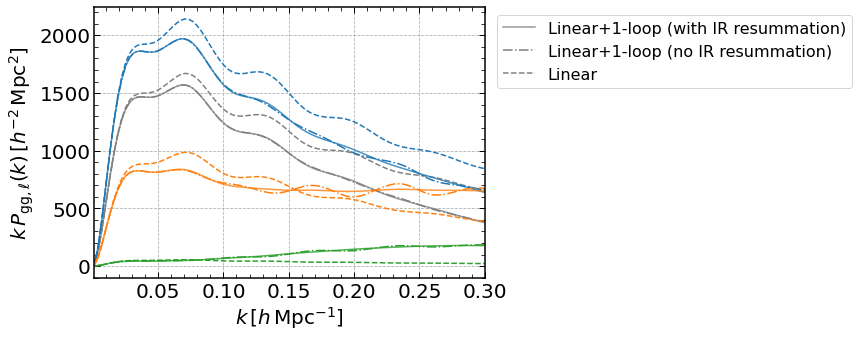

In [7]:
## Plot P_ell(k)

fig = plt.figure(figsize=(7,5))
color = plt.rcParams['axes.prop_cycle'].by_key()['color']
ax = fig.add_subplot()

k = np.linspace(1e-3,0.3,100)

# real space
pk_tree = pt.get_pk_gg_lin(k)
pk_noirres = pt.get_pk_gg(k, irres=False)
pk_irres = pt.get_pk_gg(k, irres=True)
ax.plot(k, k * pk_irres, ls='-', c='gray', alpha=0.8, label=r'Linear+1-loop (with IR resummation)')
ax.plot(k, k * pk_noirres, ls='-.', c='gray', label=r'Linear+1-loop (no IR resummation)')
ax.plot(k, k * pk_tree, ls='--', c='gray', label=r'Linear')

# redshift space multipoles
for i, l in enumerate([0,2,4]):
    pl_tree = pt.get_pk_ell_gg_lin(l, k)
    pl_noirres = pt.get_pk_ell_gg(l, k, irres=False)
    pl_irres = pt.get_pk_ell_gg(l, k, irres=True)
    ax.plot(k, k * pl_irres, ls='-', c=color[i], alpha=0.8,)
    ax.plot(k, k * pl_noirres, ls='-.', c=color[i])
    ax.plot(k, k * pl_tree, ls='--', c=color[i])
    
axs = plt.gcf().get_axes()
for ax in axs:
    plt.sca(ax)
    plt.xlabel(r'$k \, [h\,\mathrm{Mpc}^{-1}]$')
    plt.ylabel(r'$k \, P_{\mathrm{gg},\ell}(k)\,[h^{-2}\,\mathrm{Mpc}^2]$')
    plt.xlim(k.min(), k.max())
    plt.legend(fontsize=16, bbox_to_anchor=(1.01, 1.0), loc='upper left')
    plt.grid(linestyle='--')

## Local primordial non-Gaussianity

In [8]:
from power_1loop_lpng import PowerSpectrum1loopLPNG
pt = PowerSpectrum1loopLPNG()

In [9]:
## Run the Boltzamann code (CAMB)
cparam = np.array([0.02225,0.1198,0.6844,3.094,0.9645,-1.]) # Planck 2015
redshift = 0
pt.set_cosmology(cparam, redshift)

In [10]:
## Set f_NL
f_nl = 1
pt.set_f_nl(f_nl)

## Set bias parameters
bias = {'b1': 2, 'b2': -1, 'bG2': 0.1, 'bGamma3': -0.1, 'bphi': 5, 'bphid': 5}
pt.set_bias_params(bias)

## Set EFT counterterm parameters
ctr = {'c0':5, 'c2':15, 'c4':-5, 'cfog':100}
pt.set_ctr_params(ctr)

## Set stochasticity parameters
stoch = {'P_shot':-1, 'a0':0, 'a2':0} # means no stochasticity
pt.set_stoch_params(stoch1=stoch, ndens=3e-4, k_nl=0.45)

In [11]:
## Output P(k,mu) as numpy array of shape (len(k), len(mu))
k = np.linspace(1e-3,0.4,100)
mu = np.linspace(0,1,10)
pkmu = pt.get_pkmu_gg(k, mu, irres=True)

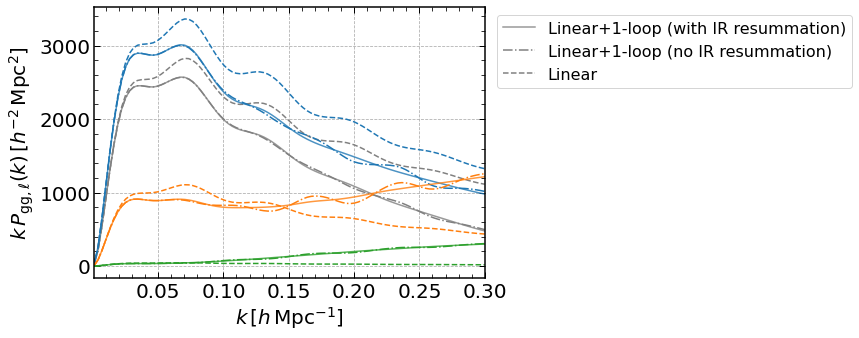

In [12]:
## Plot P_ell(k)

fig = plt.figure(figsize=(7,5))
color = plt.rcParams['axes.prop_cycle'].by_key()['color']
ax = fig.add_subplot()

k = np.linspace(1e-3,0.3,100)

# real space
pk_tree = pt.get_pk_gg_lin(k)
pk_noirres = pt.get_pk_gg(k, irres=False)
pk_irres = pt.get_pk_gg(k, irres=True)
ax.plot(k, k * pk_irres, ls='-', c='gray', alpha=0.8, label=r'Linear+1-loop (with IR resummation)')
ax.plot(k, k * pk_noirres, ls='-.', c='gray', label=r'Linear+1-loop (no IR resummation)')
ax.plot(k, k * pk_tree, ls='--', c='gray', label=r'Linear')

# redshift space multipoles
for i, l in enumerate([0,2,4]):
    pl_tree = pt.get_pk_ell_gg_lin(l, k)
    pl_noirres = pt.get_pk_ell_gg(l, k, irres=False)
    pl_irres = pt.get_pk_ell_gg(l, k, irres=True)
    ax.plot(k, k * pl_irres, ls='-', c=color[i], alpha=0.8,)
    ax.plot(k, k * pl_noirres, ls='-.', c=color[i])
    ax.plot(k, k * pl_tree, ls='--', c=color[i])
    
axs = plt.gcf().get_axes()
for ax in axs:
    plt.sca(ax)
    plt.xlabel(r'$k \, [h\,\mathrm{Mpc}^{-1}]$')
    plt.ylabel(r'$k \, P_{\mathrm{gg},\ell}(k)\,[h^{-2}\,\mathrm{Mpc}^2]$')
    plt.xlim(k.min(), k.max())
    plt.legend(fontsize=16, bbox_to_anchor=(1.01, 1.0), loc='upper left')
    plt.grid(linestyle='--')

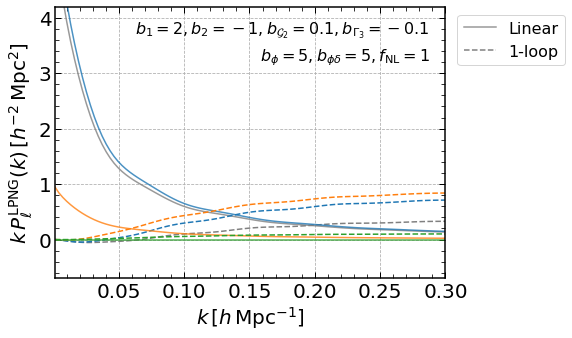

In [13]:
## Plot local PNG contributions of P_ell(k)

fig = plt.figure(figsize=(7,5))
color = plt.rcParams['axes.prop_cycle'].by_key()['color']

ax = fig.add_subplot()

bias = {'b1':2, 'b2':-1, 'bG2':0.1, 'bGamma3':-0.1, 'bphi':5, 'bphid':5}
pt.set_bias_params(bias)

f_nl = 1
pt.set_f_nl(f_nl=f_nl)

k = np.linspace(1e-3,0.3,100)

# real space
pt.set_f_nl(f_nl)
pk_png_tree = pt.get_pk_gg_lin(k)
pt.set_f_nl(0)
pk_tree = pt.get_pk_gg_lin(k)
ax.plot(k, k * (pk_png_tree - pk_tree), ls='-', c='gray', alpha=0.8, label=r'Linear')
pt.set_f_nl(f_nl)
pk_png_1loop = pt.get_pkmu_gg_1loop(k, 0, name='lpng_tot')
ax.plot(k, k * pk_png_1loop, ls='--', c='gray', label=r'1-loop')

# redshift space multipoles
for i, l in enumerate([0,2,4]):
    pt.set_f_nl(f_nl)
    pl_png_tree = pt.get_pk_ell_gg_lin(l, k)
    pt.set_f_nl(0)
    pl_tree = pt.get_pk_ell_gg_lin(l, k)
    ax.plot(k, k * (pl_png_tree - pl_tree), ls='-', c=color[i], alpha=0.8)
    pt.set_f_nl(f_nl)
    pl_png_1loop = pt.get_pk_ell_gg_1loop(l, k, name='lpng_tot')
    ax.plot(k, k * pl_png_1loop, ls='--', c=color[i], alpha=1)
pt.set_f_nl(f_nl)

ax.text(0.96, 0.9, r'$b_1=%s, b_2=%s, b_{\mathcal{G}_2}=%s, b_{\Gamma_3}=%s$' % (bias['b1'], bias['b2'], bias['bG2'], bias['bGamma3']), fontsize=16, transform=ax.transAxes, ha='right')
ax.text(0.96, 0.8, r'$b_{\phi}=%s, b_{\phi\delta}=%s, f_\mathrm{NL}=%s$' % (bias['bphi'], bias['bphid'], pt.f_nl), fontsize=16, transform=ax.transAxes, ha='right')
ax.legend(fontsize=16, bbox_to_anchor=(1.01, 1.0), loc='upper left')

axs = plt.gcf().get_axes()
for ax in axs:
    plt.sca(ax)
    plt.xlabel(r'$k\,[h\,\mathrm{Mpc}^{-1}]$')
    plt.ylabel(r'$k\,P_{\ell}^\mathrm{LPNG}(k)\,[h^{-2}\,\mathrm{Mpc}^2]$')
    plt.xlim(k.min(), k.max())
    plt.ylim(-0.7,4.2)
    plt.grid(linestyle='--')